In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import os,sys,re

if not os.path.isdir("/content/FCCNs"):
  !git clone https://github.com/saurabhya/FCCNs.git /content/FCCNs
else:
  print("FCCN already cloned")

path = '/content/FCCNs/utils.py'
code = open(path).read()
open(path, 'w').write(re.sub(r'_, term_width = os\.popen.*', 'term_width = 80', code))
sys.path.insert(0, '/content/FCCNs')
os.chdir('/content/FCCNs')

print('✅ Setup complete')

Cloning into '/content/FCCNs'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 107 (delta 57), reused 79 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 1.38 MiB | 4.94 MiB/s, done.
Resolving deltas: 100% (57/57), done.
✅ Setup complete


In [6]:
import torch,torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torchvision import transforms
from PIL import Image
import networks as models
from utils import ToHSV, ToComplex
from google.colab import files as colab_files

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)


cuda


In [7]:
model_path = "/content/drive/MyDrive/Copy of resnet152_model_best.pth.tar"
model = models.resnet152(num_classes=1000)
checkpoint = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'],strict=False)
model.to(DEVICE)

#

ResNet(
  (conv1): ComplexConv2d(
    (conv_real): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (conv_imag): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  )
  (bn1): ComplexNaiveBatchNorm2d(
    (real_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (imag_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (prelu): CPReLU(
    (real_prelu): PReLU(num_parameters=1)
    (imag_prelu): PReLU(num_parameters=1)
  )
  (maxpool): ComplexMaxPool2d(
    (max_pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): ComplexConv2d(
        (conv_real): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (conv_imag): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (bn1): ComplexNaiveBatchNorm2d(
        (real_bn): BatchNo

In [11]:
train_file_path = "/content/drive/MyDrive/NewR22/train"
test_file_path = "/content/drive/MyDrive/NewR22/test"

def load_images(path):
  images,labels=[],[]
  class_map={'Normal':0,"Defective":1}
  for class_name,class_label in class_map.items():
    folder = os.path.join(path,class_name)
    for filename in os.listdir(folder):
      img_path = os.path.join(folder,filename)
      img = Image.open(img_path).convert('RGB')
      images.append(img)
      labels.append(class_label)
  return images,labels
train_images,train_labels = load_images(train_file_path)
test_images,test_labels = load_images(test_file_path)

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    ToHSV(),
    ToComplex()
])


In [31]:
class FCCNFineTune(nn.Module):
  def __init__(self,full_model):
    super().__init__()
    self.conv1 = full_model.conv1
    self.bn1 = full_model.bn1
    self.prelu = full_model.prelu
    self.maxpool = full_model.maxpool
    self.layer1 = full_model.layer1
    self.layer2 = full_model.layer2
    self.layer3 = full_model.layer3
    self.layer4 = full_model.layer4
    self.avgpool = full_model.avgpool
    self.dropout = nn.Dropout(p=0.5)
    self.fc = nn.Linear(2048,2)
  def forward(self,x):
    x=self.conv1(x)
    x=self.bn1(x)
    x=self.prelu(x)
    x=self.maxpool(x)
    x=self.layer1(x)
    x=self.layer2(x)
    x=self.layer3(x)
    x=self.layer4(x)
    x=self.avgpool(x)
    x = x.squeeze(-1).squeeze(-1)
    x = x.abs()
    x = self.dropout(x)
    x = self.fc(x)
    return x

In [14]:
from torch.utils.data import Dataset,DataLoader

class RailDataset(Dataset):
  def __init__(self,images,labels,transform):
    self.images = images
    self.labels = labels
    self.transform = transform
  def __len__(self):
    return len(self.images)
  def __getitem__(self, index):
    img = self.images[index]
    label = self.labels[index]
    img_tensor = transform(img)
    return img_tensor,label

In [17]:
from sklearn.model_selection import train_test_split
train_img,val_img,train_label,val_label = train_test_split(
    train_images,train_labels,test_size=0.2,random_state=42,stratify=train_labels

)
train_dataset = RailDataset(train_img,train_label,transform)
val_dataset = RailDataset(val_img,val_label,transform)
test_dataset = RailDataset(test_images,test_labels,transform)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=8,shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 45
Val batches   : 12
Test batches  : 14


In [18]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
def train_one_epoch(model,loader,optimizer,criterion):
  model.train()
  total_loss,correct = 0,0
  for imgs,labels in loader:
    imgs = imgs.to(DEVICE)
    labels = labels.to(DEVICE)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    correct += (outputs.argmax(1)==labels).sum().item()
  return total_loss/len(loader),correct/len(loader.dataset)

def evaluate(model,loader,criterion):
  model.eval()
  total_loss,correct = 0,0
  with torch.no_grad():
    for imgs,labels in loader:
      imgs=imgs.to(DEVICE)
      labels=labels.to(DEVICE)
      outputs = model(imgs)
      loss = criterion(outputs,labels)
      total_loss += loss.item()
      correct += (outputs.argmax(1)==labels).sum().item()
  return total_loss/len(loader),correct/len(loader.dataset)



In [27]:
def run_training(model,train_loader,val_loader,optimizer,num_epochs):
  best_val_acc = 0
  patience = 5
  no_improve = 0
  for epoch in range(num_epochs):
    train_loss,train_acc = train_one_epoch(model,train_loader,optimizer,criterion)
    val_loss,val_acc = evaluate(model,val_loader,criterion)
    print(f'[Training] Epoch {epoch+1:2d} '
          f'| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} '
              f'| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    if val_acc>best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(),'best.pth')
      no_improve = 0
    else:
      no_improve += 1
    if no_improve>=patience:
      print(f'Early stopping at epoch {epoch+1}')
      break

  print(f"best val acc: {best_val_acc:.4f}")
  return best_val_acc

In [33]:
finetune_model = FCCNFineTune(model).to(DEVICE)
for param in finetune_model.parameters():
  param.requires_grad = True
trainable = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
print(f"Trainable parameters {trainable:,}")
optimizer = optim.Adam(finetune_model.parameters(),lr=0.00001)

run_training(finetune_model,train_loader,val_loader,optimizer,num_epochs=10)

Trainable parameters 116,291,816
[Training] Epoch  1 | Train Loss: 0.6179 Acc: 0.6676 | Val Loss: 0.3355 Acc: 0.9101
[Training] Epoch  2 | Train Loss: 0.2752 Acc: 0.9042 | Val Loss: 0.2109 Acc: 0.9213
[Training] Epoch  3 | Train Loss: 0.1579 Acc: 0.9493 | Val Loss: 0.1582 Acc: 0.9438
[Training] Epoch  4 | Train Loss: 0.1079 Acc: 0.9746 | Val Loss: 0.1183 Acc: 0.9438
[Training] Epoch  5 | Train Loss: 0.0772 Acc: 0.9803 | Val Loss: 0.1089 Acc: 0.9663
[Training] Epoch  6 | Train Loss: 0.0311 Acc: 1.0000 | Val Loss: 0.1002 Acc: 0.9551
[Training] Epoch  7 | Train Loss: 0.0349 Acc: 0.9972 | Val Loss: 0.0870 Acc: 0.9663
[Training] Epoch  8 | Train Loss: 0.0347 Acc: 0.9944 | Val Loss: 0.0716 Acc: 0.9775
[Training] Epoch  9 | Train Loss: 0.0249 Acc: 0.9972 | Val Loss: 0.0708 Acc: 0.9663
[Training] Epoch 10 | Train Loss: 0.0293 Acc: 0.9972 | Val Loss: 0.0648 Acc: 0.9775
best val acc: 0.9775


0.9775280898876404

In [35]:
test_loss, test_acc = evaluate(finetune_model, test_loader,criterion)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9369


              precision    recall  f1-score   support

      Normal       0.92      0.96      0.94        56
   Defective       0.96      0.91      0.93        55

    accuracy                           0.94       111
   macro avg       0.94      0.94      0.94       111
weighted avg       0.94      0.94      0.94       111



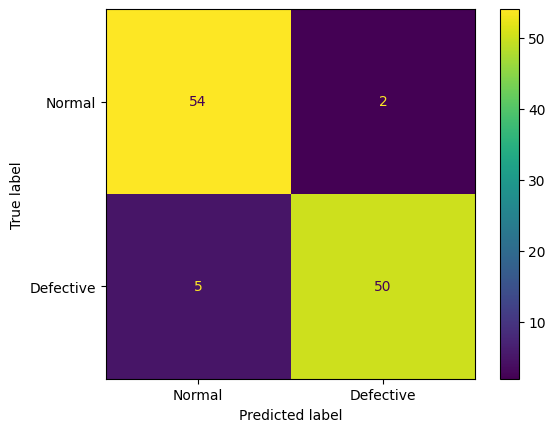

In [37]:
all_preds, all_labels = [], []
finetune_model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = finetune_model(imgs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix
print(classification_report(all_labels, all_preds,
      target_names=['Normal','Defective']))
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Normal','Defective'])
disp.plot()
plt.show()